In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import random
import seaborn as sns

In [2]:
path = ' ' #fill this in yourself
LOO_diffq =pd.read_csv(f"{path}/data_frame_for_each_mouse_date_over_finer_q_values_between_0_and_1.csv")

In [3]:
foot =pd.read_csv(f'{path}/data_frame_for_each_mouse_date_over_finer_q_values_between_0_and_1_after_34th.csv')

In [7]:
vals = pd.concat([LOO_diffq,foot]).reset_index(drop=True)
vals = vals.iloc[:, :-1]

In [9]:
loo1to2 =pd.read_csv(f'{path}/data_frame_for_each_mouse_date_over_finer_q_values_between_1_and_2.csv')

In [11]:
merged_df = pd.merge(vals, loo1to2, on=['Mouse', 'Date'])

### plot fig 6a

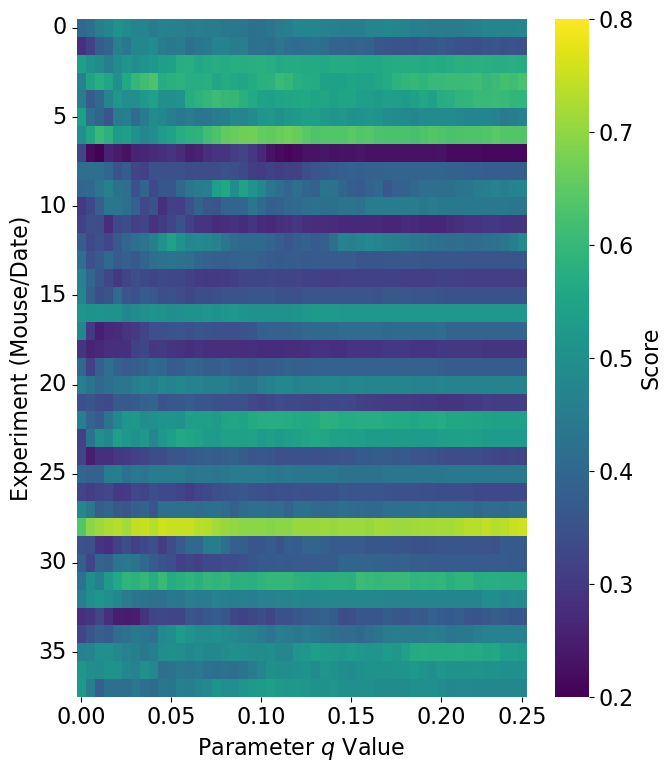

In [16]:
param_cols = merged_df.columns[2:52] 
scores = merged_df[param_cols].copy()

plt.rcParams.update({'font.size': 16})
plt.figure(figsize=(7, 8))
sns.heatmap(scores,vmin=0.2,vmax=0.8, cmap='viridis', cbar_kws={'label': 'Score'}, xticklabels=False, yticklabels=1)

plt.xlabel(r'Parameter $q$ Value')
plt.ylabel('Experiment (Mouse/Date)')

ax = plt.gca()

# Set y-axis ticks for every other row
num_rows = scores.shape[0]
every_other = np.arange(0, num_rows, 5)
ax.set_yticks(every_other + 0.5)
ax.set_yticklabels([f'{i}' for i in every_other])

xtick_values = np.round(np.arange(0.0, 0.26, 0.05), decimals=2)  # 0.00, 0.05, ..., 0.25
param_values = np.array([float(col) for col in param_cols])
xtick_positions = [np.argmin(np.abs(param_values - val)) + 0.5 for val in xtick_values]


ax.set_xticks(xtick_positions)
ax.set_xticklabels([f'{val:.2f}' for val in xtick_values])

plt.tight_layout()
#plt.savefig('stability_for_small_q_vals.svg', dpi=300, bbox_inches='tight', format='svg')
plt.show()

### plot fig 6b

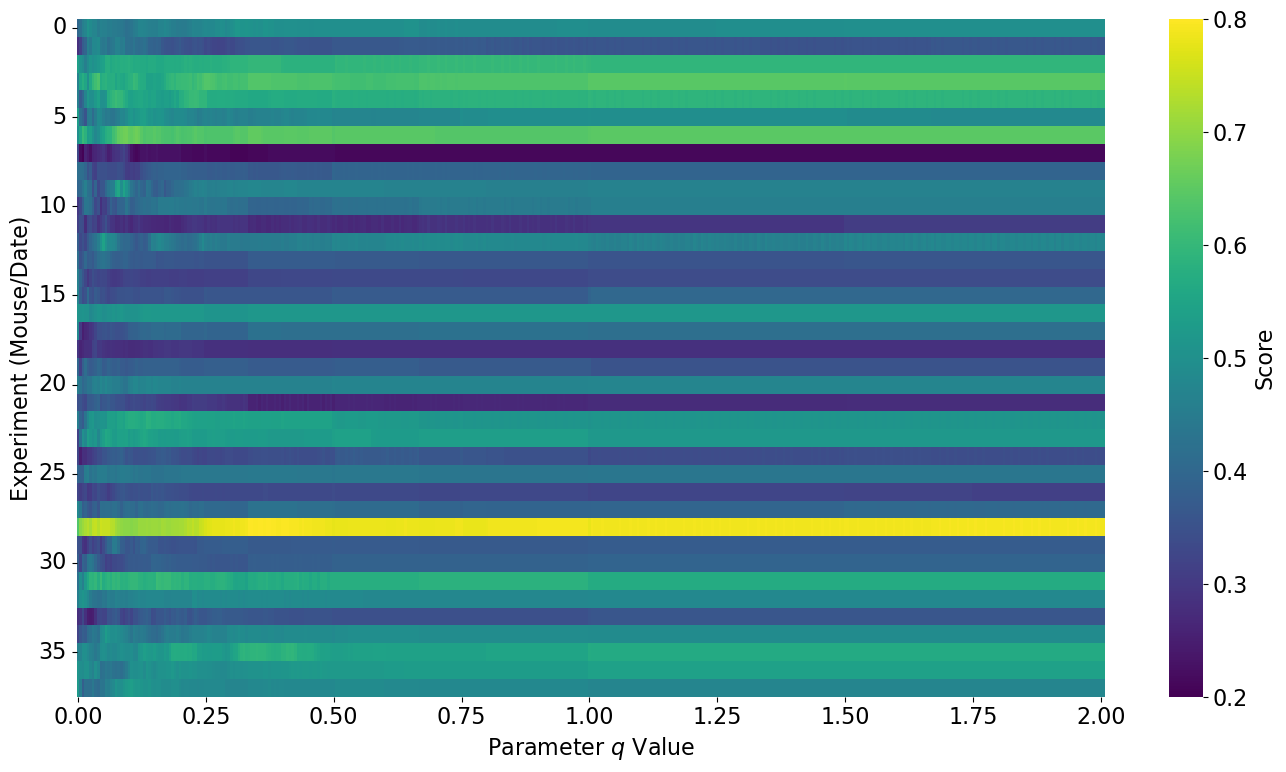

In [21]:
param_cols = merged_df.columns[2:] 
scores = merged_df[param_cols].copy()

plt.rcParams.update({'font.size': 16})
plt.figure(figsize=(14, 8))
sns.heatmap(scores,vmin=0.2,vmax=0.8, cmap='viridis', cbar_kws={'label': 'Score'}, xticklabels=False, yticklabels=1)

plt.xlabel(r'Parameter $q$ Value')
plt.ylabel('Experiment (Mouse/Date)')


ax = plt.gca()
num_rows = scores.shape[0]
every_other = np.arange(0, num_rows, 5)
ax.set_yticks(every_other + 0.5)
ax.set_yticklabels([f'{i}' for i in every_other])
xtick_values = np.arange(0.0, 2.01, 0.25) 
xtick_labels = [f'{x:.2f}' for x in xtick_values]

param_values = np.array([float(col) for col in param_cols])
xtick_positions = [np.where(param_values == val)[0][0] + 0.5 for val in xtick_values if val in param_values]

ax.set_xticks(xtick_positions)
ax.set_xticklabels([f'{val:.2f}' for val in xtick_values if val in param_values])

plt.tight_layout()
#plt.savefig('stability_for_all_q_vals.svg', dpi=300, bbox_inches='tight', format='svg')
plt.show()


## read-in mean LOU scores from gc 3temps

In [24]:
realsummary_df = pd.read_csv(f'{path}/q2005_3temp_GC_temp_networks_summary.csv')

In [26]:
realdetailedLOO_df = pd.read_csv(f'{path}/q2005_3temp_GC_temp_networks_detailedLOOscores.csv')

In [33]:
merged_df = pd.read_csv(f'{path}/gctemp_sna_withMDpair_info.csv')

In [37]:
from scipy.stats import ttest_1samp, ttest_ind

merged_df = merged_df.rename(columns={'MouseID':'Mouse'})
chance = 1/3
results = []

for (mouse, date), loo_group in realdetailedLOO_df.groupby(['Mouse','Date']):
    sna_group = merged_df[(merged_df['Mouse']==mouse) & (merged_df['Date']==date)]
    if sna_group.empty:
        continue
    
    loo_scores = loo_group['LOU_Score'].values
    sna_scores = sna_group['SNAscore'].values
    
    p_loo = ttest_1samp(loo_scores, chance).pvalue
    p_sna = ttest_1samp(sna_scores, chance).pvalue
    p_between = ttest_ind(loo_scores, sna_scores, equal_var=False).pvalue
    
    results.append([mouse, date, p_loo, p_sna, p_between, p_loo < 0.05, p_sna < 0.05, p_between < 0.05])

significance_df = pd.DataFrame(results, columns=['Mouse','Date','p_LOO_vs_chance','p_SNA_vs_chance','p_between_methods',
                                                 'sig_LOO_vs_chance','sig_SNA_vs_chance','sig_between_methods'])

In [39]:
significance_df

,Mouse,Date,p_LOO_vs_chance,p_SNA_vs_chance,p_between_methods,sig_LOO_vs_chance,sig_SNA_vs_chance,sig_between_methods
0,CB278,121521,1.384583e-12,0.000019,0.000002,True,True,True
1,CB278,121721,5.952679e-12,0.000949,0.000349,True,True,True
2,CB278,121921,6.074745e-09,0.028774,0.083052,True,True,False
3,CB279,121421,1.919985e-02,0.012821,0.570138,True,True,False
4,CB279,121621,1.296031e-09,0.050968,0.735050,True,False,False
5,CB279,122021,1.749326e-09,0.009695,0.007932,True,True,True
6,CB280,121521,1.569099e-13,0.008809,0.034495,True,True,True
7,CB280,121721,2.594643e-01,0.591588,0.954380,False,False,False
8,CB289,40422,2.354383e-12,0.013015,0.000004,True,True,True
9,CB293,40222,1.842790e-03,0.125658,0.145320,True,False,False


In [41]:
significance_df["higher_method"] = np.where(
    significance_df["sig_between_methods"],
    np.where(
        significance_df["Mouse"].map(lambda m: realdetailedLOO_df[realdetailedLOO_df["Mouse"]==m]["LOU_Score"].mean()) > 
        significance_df["Mouse"].map(lambda m: merged_df[merged_df["Mouse"]==m]["SNAscore"].mean()),"LOO", "SNA"),None)

In [43]:
significance_df

,Mouse,Date,p_LOO_vs_chance,p_SNA_vs_chance,p_between_methods,sig_LOO_vs_chance,sig_SNA_vs_chance,sig_between_methods,higher_method
0,CB278,121521,1.384583e-12,0.000019,0.000002,True,True,True,LOO
1,CB278,121721,5.952679e-12,0.000949,0.000349,True,True,True,LOO
2,CB278,121921,6.074745e-09,0.028774,0.083052,True,True,False,None
3,CB279,121421,1.919985e-02,0.012821,0.570138,True,True,False,None
4,CB279,121621,1.296031e-09,0.050968,0.735050,True,False,False,None
5,CB279,122021,1.749326e-09,0.009695,0.007932,True,True,True,LOO
6,CB280,121521,1.569099e-13,0.008809,0.034495,True,True,True,LOO
7,CB280,121721,2.594643e-01,0.591588,0.954380,False,False,False,None
8,CB289,40422,2.354383e-12,0.013015,0.000004,True,True,True,LOO
9,CB293,40222,1.842790e-03,0.125658,0.145320,True,False,False,None


In [46]:
#this filters the dataframe to only contain methods that are at least once greater than chance
signif_any_df = significance_df[significance_df["sig_LOO_vs_chance"] | significance_df["sig_SNA_vs_chance"]].reset_index(drop=True)

In [48]:
signif_any_df

,Mouse,Date,p_LOO_vs_chance,p_SNA_vs_chance,p_between_methods,sig_LOO_vs_chance,sig_SNA_vs_chance,sig_between_methods,higher_method
0,CB278,121521,1.384583e-12,0.000019,0.000002,True,True,True,LOO
1,CB278,121721,5.952679e-12,0.000949,0.000349,True,True,True,LOO
2,CB278,121921,6.074745e-09,0.028774,0.083052,True,True,False,None
3,CB279,121421,1.919985e-02,0.012821,0.570138,True,True,False,None
4,CB279,121621,1.296031e-09,0.050968,0.735050,True,False,False,None
5,CB279,122021,1.749326e-09,0.009695,0.007932,True,True,True,LOO
6,CB280,121521,1.569099e-13,0.008809,0.034495,True,True,True,LOO
7,CB289,40422,2.354383e-12,0.013015,0.000004,True,True,True,LOO
8,CB293,40222,1.842790e-03,0.125658,0.145320,True,False,False,None
9,CB293,40422,4.737007e-06,0.057898,0.003519,True,False,True,LOO


### plot fig 8

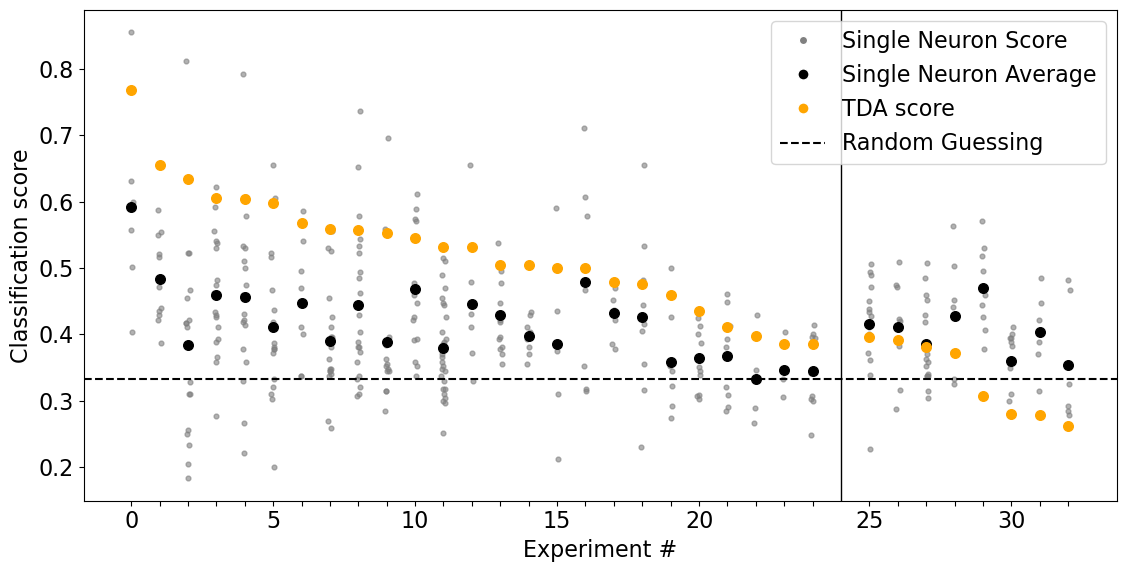

In [59]:
merged_df = merged_df.rename(columns={'MouseID':'Mouse'})

agg_loo = realdetailedLOO_df.groupby(['Mouse','Date'])['LOU_Score'].agg(['mean','size']).rename(columns={'mean':'mean_LOO','size':'n_LOO'}).reset_index()
agg_sna = merged_df.groupby(['Mouse','Date'])['SNAscore'].agg(['mean','size', list]).rename(columns={'mean':'mean_SNA','size':'n_SNA', 'list':'sna_points'}).reset_index()

agg = agg_loo.merge(agg_sna, on=['Mouse','Date'], how='inner')
agg = agg.merge(significance_df[['Mouse','Date','sig_LOO_vs_chance','sig_SNA_vs_chance']], on=['Mouse','Date'], how='left').fillna(False)

sel = agg[(agg['sig_LOO_vs_chance']) | (agg['sig_SNA_vs_chance'])].copy()
#left = sel[sel['mean_LOO'] > sel['mean_SNA']].sort_values('mean_LOO', ascending=False).reset_index(drop=True)
#right = sel[sel['mean_SNA'] >= sel['mean_LOO']].sort_values('mean_SNA', ascending=True).reset_index(drop=True)

left = sel[sel['mean_LOO'] > sel['mean_SNA']].sort_values('mean_LOO', ascending=False).reset_index(drop=True)

# NEW ordering for the right side: decreasing LOO score
right = sel[sel['mean_SNA'] >= sel['mean_LOO']].sort_values('mean_LOO', ascending=False).reset_index(drop=True)


left_x = -np.arange(len(left),0,-1)
right_x = np.arange(1, len(right)+1)
left['x'] = left_x
right['x'] = right_x
plot_df = pd.concat([left, right], ignore_index=True)

fig, ax = plt.subplots(figsize=(max(8, len(plot_df)*0.35), 6))
ax.axvline(0, color='k', linewidth=1)

for _, row in plot_df.iterrows():
    x = row['x']
    sna_pts = row['sna_points']
    jitter = (np.random.rand(len(sna_pts)) - 0.5) * 0.15
    ax.scatter(np.full(len(sna_pts), x) + jitter, sna_pts, s=12, alpha=0.6, color='grey', zorder=1)
    ax.scatter(x, row['mean_SNA'], s=48, color='black', zorder=3, label='_nolegend_')
    ax.scatter(x, row['mean_LOO'], s=48, color='orange', marker='o', zorder=4, label='_nolegend_')

ticks = plot_df['x'].values
plt.axhline(y=0.333, color='black', linestyle='--')
labels = [f"{i+1}" for i in range(len(plot_df))]
# experiment numbers from 1..N
exp_nums = np.arange(1, len(plot_df)+1)

# pick every 5th experiment for labeling
tick_indices = exp_nums[exp_nums % 5 == 0]

# corresponding x positions
tick_positions = plot_df['x'].iloc[tick_indices - 1]

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_indices)


ax.set_xlabel('Experiment #')
ax.set_ylabel('Classification score')
#ax.set_title('Per-experiment SNA points (grey), SNA mean (black) and LOO mean (orange)\n(only experiments with at least one method significant vs chance)')
legend_handles = [
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='grey', markersize=6, label='Single Neuron Score'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='black', markersize=8, label='Single Neuron Average'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='orange', markersize=8, label='TDA score'),
    Line2D([0], [0], color='black', linestyle='--', label='Random Guessing')
]
ax.legend(handles=legend_handles, loc='best')

# x positions for all experiments
all_x = plot_df['x']

# tick positions at every experiment
ax.set_xticks(all_x)

# labels only for every 5th experiment, empty string otherwise
ax.set_xticklabels([str(i) if i % 5 == 0 else '' for i in range(len(plot_df))])
plt.tight_layout()
plt.savefig('tda_vs_single_neuron_nobadexp.svg', format='svg')
plt.savefig('tda_vs_single_neuron_nobadexp.pdf', format='pdf')
plt.show()

